原始图片: size=(600, 400), mode=RGB


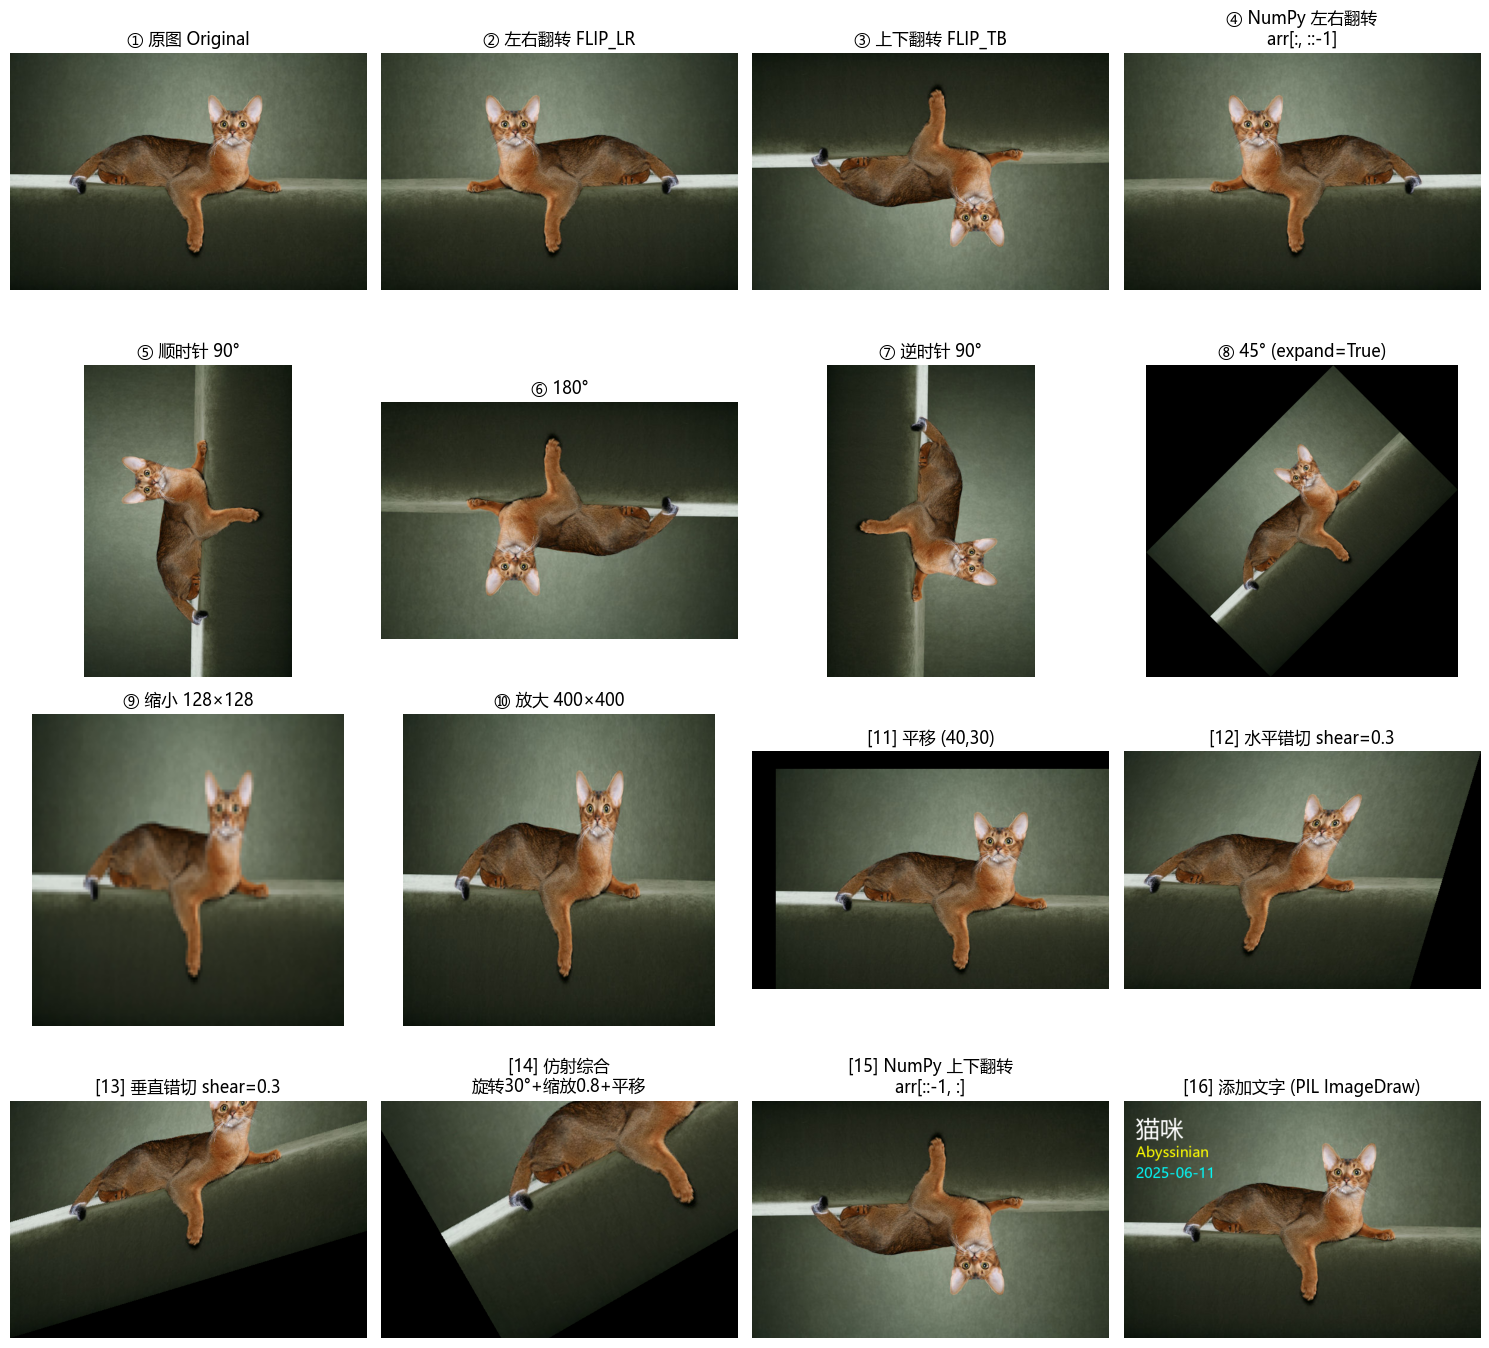


📐 PIL 几何变换 API 速查表

┌─────────────────┬──────────────────────────────┬──────────────────┐
│ 变换             │ 方法                         │ 关键参数          │
├─────────────────┼──────────────────────────────┼──────────────────┤
│ 水平翻转         │ img.transpose(FLIP_LEFT_RIGHT)│ —                │
│ 垂直翻转         │ img.transpose(FLIP_TOP_BOTTOM) │ —                │
│ 旋转 90/180/270  │ img.transpose(ROTATE_90/...)  │ —                │
│ 任意角度旋转     │ img.rotate(angle)              │ expand=True      │
│ 缩放             │ img.resize((w, h))             │ Image.LANCZOS    │
│ 平移             │ NumPy 切片/Image.transform     │ 仿射矩阵 c, f    │
│ 错切             │ img.transform(..., AFFINE, m)  │ 仿射矩阵 b, d    │
│ 仿射变换         │ img.transform(..., AFFINE, m)  │ 6参数矩阵        │
│ NumPy 左右翻转   │ arr[:, ::-1]                   │ 列逆序           │
│ NumPy 上下翻转   │ arr[::-1, :]                   │ 行逆序           │
│ NumPy 转置       │ arr.transpose(1,0,2)           │ 交换行列轴       │
│ 添加文字         │ ImageDraw.text(xy,

In [2]:
# ============================================================
# 图片的几何变换 —— 使用猫咪图片演示
# 几何变换：翻转、旋转、缩放、平移、错切、仿射
# ============================================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ---------- 设置中文字体（防止标题显示为方框）----------
# Windows 常见中文字体：Microsoft YaHei, SimHei, DengXian 等
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示异常

# ---------- 打开图片 ----------
img = Image.open('images/Abyssinian_1.jpg').convert('RGB')
arr = np.array(img)
print(f"原始图片: size={img.size}, mode={img.mode}")

# ============================================================
# 1. 翻转（Flip）—— 镜像
# ============================================================
#    Image.transpose() 参数：
#      FLIP_LEFT_RIGHT  → 水平翻转（左右镜像）
#      FLIP_TOP_BOTTOM  → 垂直翻转（上下颠倒）
# ============================================================
flip_lr = img.transpose(Image.FLIP_LEFT_RIGHT)   # 左右翻转
flip_tb = img.transpose(Image.FLIP_TOP_BOTTOM)    # 上下翻转

# ============================================================
# 2. 旋转（Rotation）
# ============================================================
#    方法一：transpose() —— 只支持 90°/180°/270°（不改变尺寸）
#    方法二：rotate()    —— 任意角度（可选 expand 保持完整内容）
# ============================================================
rot_90  = img.transpose(Image.ROTATE_90)          # 顺时针 90°
rot_180 = img.transpose(Image.ROTATE_180)         # 180°
rot_270 = img.transpose(Image.ROTATE_270)         # 顺时针 270°（=逆时针 90°）

rot_45  = img.rotate(45)                          # 任意角度 45°（裁切边角）
rot_45e = img.rotate(45, expand=True)             # expand=True 保留完整内容

# ============================================================
# 3. 缩放（Resize）
# ============================================================
scale_down = img.resize((128, 128))               # 缩小
scale_up   = img.resize((400, 400))               # 放大

# ============================================================
# 4. 平移（Translation）—— 用 NumPy 数组操作
# ============================================================
h, w = arr.shape[:2]
shift_x, shift_y = 40, 30                         # 向右移40px，向下移30px

# 创建一个空白画布，把原图贴到偏移后的位置
translated = np.zeros_like(arr)
translated[shift_y:shift_y+h-shift_y, shift_x:shift_x+w-shift_x] = arr[:h-shift_y, :w-shift_x]

# ============================================================
# 5. 错切（Shear）—— 用 Image.transform() 做仿射变换
# ============================================================
#    仿射矩阵 [a, b, c, d, e, f] 对应公式：
#      x' = a*x + b*y + c
#      y' = d*x + e*y + f
#    错切：b≠0 水平错切，d≠0 垂直错切
# ============================================================
# 水平错切（shear_x）：保持 y 不变，x 随 y 偏移
shear_val = 0.3
affine_shear_x = (1, shear_val, 0,  0, 1, 0)     # x' = x + 0.3*y
shear_x = img.transform(img.size, Image.AFFINE, affine_shear_x)

# 垂直错切（shear_y）：保持 x 不变，y 随 x 偏移
affine_shear_y = (1, 0, 0,  shear_val, 1, 0)     # y' = 0.3*x + y
shear_y = img.transform(img.size, Image.AFFINE, affine_shear_y)

# ============================================================
# 6. 综合仿射变换 —— 同时旋转 + 缩放 + 平移
# ============================================================
#    30° 旋转 + 缩小 0.8 倍 + 平移 (20, 10)
import math
theta = math.radians(30)
cos_t, sin_t = math.cos(theta), math.sin(theta)
scale = 0.8
affine_all = (cos_t*scale, -sin_t*scale, 20,
              sin_t*scale,  cos_t*scale, 10)
affine_all_img = img.transform(img.size, Image.AFFINE, affine_all)

# ============================================================
# 7. 用 NumPy 手动实现水平翻转（理解底层原理）
# ============================================================
flip_lr_np = arr[:, ::-1]        # 列逆序 → 左右翻转
flip_tb_np = arr[::-1, :]        # 行逆序 → 上下翻转

# ============================================================
# 8. 在图片上添加文字 —— 用 PIL ImageDraw
# ============================================================
from PIL import ImageDraw, ImageFont

img_text = img.copy()
draw = ImageDraw.Draw(img_text)

# Windows 系统字体路径（微软雅黑）
font_path = 'C:/Windows/Fonts/msyh.ttc'
font_large = ImageFont.truetype(font_path, 40)
font_small = ImageFont.truetype(font_path, 24)

# 添加文字（坐标、内容、颜色）
draw.text((20, 20),  "猫咪",    font=font_large, fill=(255, 255, 255))  # 白字
draw.text((20, 70),  "Abyssinian", font=font_small, fill=(255, 255, 0))  # 黄字
draw.text((20, 105), "2025-06-11", font=font_small, fill=(0, 255, 255))  # 青字

# ============================================================
# 绘制对比图
# ============================================================
fig, axes = plt.subplots(4, 4, figsize=(15, 14))

# 第1行：原图 + 翻转
axes[0, 0].imshow(arr)
axes[0, 0].set_title("① 原图 Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(flip_lr)
axes[0, 1].set_title("② 左右翻转 FLIP_LR")
axes[0, 1].axis('off')

axes[0, 2].imshow(flip_tb)
axes[0, 2].set_title("③ 上下翻转 FLIP_TB")
axes[0, 2].axis('off')

axes[0, 3].imshow(flip_lr_np)
axes[0, 3].set_title("④ NumPy 左右翻转\narr[:, ::-1]")
axes[0, 3].axis('off')

# 第2行：旋转
axes[1, 0].imshow(rot_90)
axes[1, 0].set_title("⑤ 顺时针 90°")
axes[1, 0].axis('off')

axes[1, 1].imshow(rot_180)
axes[1, 1].set_title("⑥ 180°")
axes[1, 1].axis('off')

axes[1, 2].imshow(rot_270)
axes[1, 2].set_title("⑦ 逆时针 90°")
axes[1, 2].axis('off')

axes[1, 3].imshow(rot_45e)
axes[1, 3].set_title("⑧ 45° (expand=True)")
axes[1, 3].axis('off')

# 第3行：缩放 + 平移 + 错切
axes[2, 0].imshow(scale_down)
axes[2, 0].set_title("⑨ 缩小 128×128")
axes[2, 0].axis('off')

axes[2, 1].imshow(scale_up)
axes[2, 1].set_title("⑩ 放大 400×400")
axes[2, 1].axis('off')

axes[2, 2].imshow(translated)
axes[2, 2].set_title(f"[11] 平移 ({shift_x},{shift_y})")
axes[2, 2].axis('off')

axes[2, 3].imshow(shear_x)
axes[2, 3].set_title(f"[12] 水平错切 shear=0.3")
axes[2, 3].axis('off')

# 第4行：错切 + 仿射 + NumPy 翻转
axes[3, 0].imshow(shear_y)
axes[3, 0].set_title("[13] 垂直错切 shear=0.3")
axes[3, 0].axis('off')

axes[3, 1].imshow(affine_all_img)
axes[3, 1].set_title("[14] 仿射综合\n旋转30°+缩放0.8+平移")
axes[3, 1].axis('off')

axes[3, 2].imshow(flip_tb_np)
axes[3, 2].set_title("[15] NumPy 上下翻转\narr[::-1, :]")
axes[3, 2].axis('off')

axes[3, 3].imshow(img_text)
axes[3, 3].set_title("[16] 添加文字 (PIL ImageDraw)")
axes[3, 3].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 总结：PIL 几何变换 API 速查
# ============================================================
print("\n" + "="*65)
print("📐 PIL 几何变换 API 速查表")
print("="*65)
print("""
┌─────────────────┬──────────────────────────────┬──────────────────┐
│ 变换             │ 方法                         │ 关键参数          │
├─────────────────┼──────────────────────────────┼──────────────────┤
│ 水平翻转         │ img.transpose(FLIP_LEFT_RIGHT)│ —                │
│ 垂直翻转         │ img.transpose(FLIP_TOP_BOTTOM) │ —                │
│ 旋转 90/180/270  │ img.transpose(ROTATE_90/...)  │ —                │
│ 任意角度旋转     │ img.rotate(angle)              │ expand=True      │
│ 缩放             │ img.resize((w, h))             │ Image.LANCZOS    │
│ 平移             │ NumPy 切片/Image.transform     │ 仿射矩阵 c, f    │
│ 错切             │ img.transform(..., AFFINE, m)  │ 仿射矩阵 b, d    │
│ 仿射变换         │ img.transform(..., AFFINE, m)  │ 6参数矩阵        │
│ NumPy 左右翻转   │ arr[:, ::-1]                   │ 列逆序           │
│ NumPy 上下翻转   │ arr[::-1, :]                   │ 行逆序           │
│ NumPy 转置       │ arr.transpose(1,0,2)           │ 交换行列轴       │
│ 添加文字         │ ImageDraw.text(xy, text, font) │ fill 颜色        │
└─────────────────┴──────────────────────────────┴──────────────────┘
""")


验证码: Te11


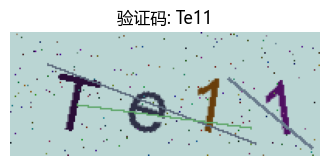

已保存: captcha_demo.png


In [72]:
# ============================================================
# PIL 生成随机验证码（带字符随机旋转）
# 0~9 (ASCII 48~57), A~Z (65~90), a~z (97~122)
# ============================================================
from PIL import Image, ImageDraw, ImageFont
import random
import os
import math

# ---------- 1. 生成随机字符 ----------
def random_char():
    """从 0~9、A~Z、a~z 中随机选一个字符"""
    choice = random.randint(0, 2)
    if choice == 0:          # 数字 0~9
        ascii_code = random.randint(48, 57)
    elif choice == 1:        # 大写字母 A~Z
        ascii_code = random.randint(65, 90)
    else:                    # 小写字母 a~z
        ascii_code = random.randint(97, 122)
    return chr(ascii_code)

# ---------- 2. 生成随机颜色 ----------
def random_color(min_val=0, max_val=255):
    """返回一个随机 RGB 颜色元组"""
    return (random.randint(min_val, max_val),
            random.randint(min_val, max_val),
            random.randint(min_val, max_val))

# ---------- 3. 配置 ----------
CODE_LEN = 4                  # 验证码位数
IMG_W, IMG_H = 200, 80        # 图片尺寸

# 字体（用微软雅黑，或系统中任意支持字母数字的字体）
font_path = 'C:/Windows/Fonts/arial.ttf'  # Arial 显示字母数字更清晰
if not os.path.exists(font_path):
    font_path = 'C:/Windows/Fonts/msyh.ttc'
font_size = 48
font = ImageFont.truetype(font_path, font_size)

# ---------- 4. 画图生成验证码 ----------
# 4a. 创建画布 + 随机背景色
img = Image.new('RGB', (IMG_W, IMG_H), random_color(100, 230))
draw = ImageDraw.Draw(img)

# 4b. 生成验证码字符串，逐个字符绘制（带旋转）
code = ''
x_start = 20
for i in range(CODE_LEN):
    ch = random_char()                    # 随机选一个字符
    code += ch

    # 随机字体颜色（避开浅色）
    fg_color = random_color(0, 120)

    # ---- 字符旋转 ----
    # ① 先在一个小 RGBA 画布上画字符
    char_img = Image.new('RGBA', (50, 60), (0, 0, 0, 0))  # 透明底
    char_draw = ImageDraw.Draw(char_img)
    char_draw.text((0, 0), ch, font=font, fill=(*fg_color, 255))

    # ② 随机旋转 -30° ~ +30°
    angle = random.randint(-30, 30)
    char_rotated = char_img.rotate(angle, expand=True, center=(25, 30))

    # ③ 随机上下偏移
    y_offset = random.randint(-5, 10)

    # ④ 粘贴到主图（用 Alpha 通道做 mask，保留透明背景）
    img.paste(char_rotated, (x_start, 10 + y_offset), char_rotated)

    x_start += random.randint(40, 48)     # 随机间距

# 4c. 加点噪点干扰（随机小点）
for _ in range(200):
    xy = (random.randint(0, IMG_W), random.randint(0, IMG_H))
    draw.point(xy, fill=random_color(0, 150))

# 4d. 加几根随机干扰线
for _ in range(3):
    x1, y1 = random.randint(0, IMG_W), random.randint(0, IMG_H)
    x2, y2 = random.randint(0, IMG_W), random.randint(0, IMG_H)
    draw.line((x1, y1, x2, y2), fill=random_color(80, 180), width=2)

print(f"验证码: {code}")

# ---------- 5. 显示并保存 ----------
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 2))
plt.imshow(img)
plt.axis('off')
plt.title(f"验证码: {code}")
plt.show()

img.save('captcha_demo.png')
print("已保存: captcha_demo.png")


## 进阶版：波浪扭曲验证码（抗 CNN）

简单旋转+噪点对 CNN 来说等于"睁眼认"。下面加 **正弦波扭曲**，让字符形状发生非线性变形，CNN 的特征提取就难多了。


  扭曲强度=0.40
验证码: kBSY0
波浪参数: amp=(3.3,1.9), freq=(0.086,0.059)


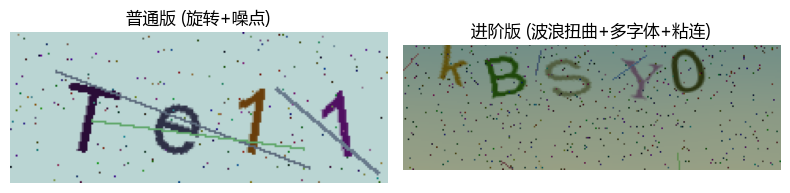

已保存: captcha_advanced.png

📌 进阶版防 CNN 原理：
━━━━━━━━━━━━━━━━━━━━━━━━━
① 正弦波扭曲 → 字符形状非线性变形，CNN 的平移不变性失效
② 多字体混用 → 同个字母特征分布变散，分类面更难学
③ 字符粘连    → 分割难度↑，CNN 需要先做字符定位
④ 渐变背景    → 简单阈值分割失效
⑤ 细密噪点    → 高频噪声干扰卷积核提取边缘特征
━━━━━━━━━━━━━━━━━━━━━━━━━



In [ ]:
from PIL import Image, ImageDraw, ImageFont
import random, os, math
import numpy as np

# ---------- 复用之前的辅助函数 ----------
def random_char():
    choice = random.randint(0, 2)
    if choice == 0:
        ascii_code = random.randint(48, 57)
    elif choice == 1:
        ascii_code = random.randint(65, 90)
    else:
        ascii_code = random.randint(97, 122)
    return chr(ascii_code)

def random_color(min_val=0, max_val=255):
    return (random.randint(min_val, max_val),
            random.randint(min_val, max_val),
            random.randint(min_val, max_val))

# ---------- 1. 配置 ----------
CODE_LEN = 5                  # 增加到5位
IMG_W, IMG_H = 240, 80
code = ''

# 准备多个字体（不同风格）
font_paths = []
if os.path.exists('C:/Windows/Fonts/arial.ttf'):
    font_paths.append('C:/Windows/Fonts/arial.ttf')
if os.path.exists('C:/Windows/Fonts/msyh.ttc'):
    font_paths.append('C:/Windows/Fonts/msyh.ttc')
if os.path.exists('C:/Windows/Fonts/times.ttf'):
    font_paths.append('C:/Windows/Fonts/times.ttf')
if os.path.exists('C:/Windows/Fonts/verdana.ttf'):
    font_paths.append('C:/Windows/Fonts/verdana.ttf')
if not font_paths:
    font_paths.append('C:/Windows/Fonts/arial.ttf')

# ---------- 2. 在临时大图上画字符（留足边距）----------
margin = 30
tmp_w = IMG_W + 2 * margin
tmp_h = IMG_H + 2 * margin

# 渐变背景（比纯色更难分割）
bg_arr = np.zeros((tmp_h, tmp_w, 3), dtype=np.uint8)
c1 = np.array(random_color(100, 180), dtype=np.uint8)  # 起始色
c2 = np.array(random_color(100, 180), dtype=np.uint8)  # 结束色
for y in range(tmp_h):
    ratio = y / tmp_h
    color = ((1 - ratio) * c1 + ratio * c2).astype(np.uint8)
    bg_arr[y, :] = color

tmp_img = Image.fromarray(bg_arr)
tmp_draw = ImageDraw.Draw(tmp_img)

x_start = 30
for i in range(CODE_LEN):
    ch = random_char()
    code += ch

    # 每个字符用随机字体、随机大小（范围收窄，避免过大/过小）
    fp = random.choice(font_paths)
    fs = random.randint(38, 46)       # 原36~50，收窄
    font = ImageFont.truetype(fp, fs)

    fg_color = random_color(10, 100)

    # 每个字符独立画在透明图层上 → 旋转
    char_img = Image.new('RGBA', (60, 80), (0, 0, 0, 0))
    char_draw = ImageDraw.Draw(char_img)
    char_draw.text((0, 0), ch, font=font, fill=(*fg_color, 255))

    angle = random.randint(-25, 25)   # 原-35~35，减小防止过度倾斜
    char_rotated = char_img.rotate(angle, expand=True, center=(30, 40))

    y_off = random.randint(-6, 10)    # 原-8~12
    tmp_img.paste(char_rotated, (x_start, 20 + y_off), char_rotated)

    # 字符间距随机（部分重叠，粘连效果）
    x_start += random.randint(32, 46)  # 原30~48，略微收紧

# ---------- 3. 正弦波扭曲（核心！）----------
arr = np.array(tmp_img)
h, w = arr.shape[:2]

# ---- 限制扭曲强度，保证人眼可读 ----
# amp 越大扭曲越狠，freq 越大波浪越密
# 调大 → 更难识别（人也认不出），调小 → 更容易被 CNN 破解
max_attempts = 10
for attempt in range(max_attempts):
    amp_x = random.uniform(2.0, 4.5)     # 水平振幅 (原3~6，收窄)
    amp_y = random.uniform(1.5, 3.0)     # 垂直振幅 (原2~4，收窄)
    freq_x = random.uniform(0.06, 0.12)  # 水平频率 (原0.08~0.15，收窄)
    freq_y = random.uniform(0.04, 0.08)  # 垂直频率 (原0.05~0.10，收窄)
    # 综合扭曲强度 = amp_x * freq_x + amp_y * freq_y
    distortion = amp_x * freq_x + amp_y * freq_y
    if 0.3 <= distortion <= 0.8:         # 这个范围内人眼勉强可读
        break
print(f"  扭曲强度={distortion:.2f} (尝试{attempt+1}次)" if distortion < 0.3 or distortion > 0.8 else f"  扭曲强度={distortion:.2f}")

# 生成扭曲坐标映射
xs, ys = np.meshgrid(np.arange(w), np.arange(h))
# 水平方向正弦扭曲 + 垂直方向正弦扭曲
map_x = xs + amp_x * np.sin(ys * freq_x) + amp_y * np.cos(xs * freq_y)
map_y = ys + amp_y * np.sin(xs * freq_y) + amp_x * np.cos(ys * freq_x)

# 限制在边界内
map_x = np.clip(map_x, 0, w - 1).astype(np.float32)
map_y = np.clip(map_y, 0, h - 1).astype(np.float32)

# 用 remap 实现扭曲（比逐像素快得多）
import cv2
warped = cv2.remap(arr, map_x, map_y, cv2.INTER_LINEAR)

# 裁剪回目标大小（去掉边距）
crop_y1 = margin
crop_y2 = margin + IMG_H
crop_x1 = margin
crop_x2 = margin + IMG_W
warped = warped[crop_y1:crop_y2, crop_x1:crop_x2]

img_advanced = Image.fromarray(warped)
draw_advanced = ImageDraw.Draw(img_advanced)

# ---------- 4. 额外干扰 ----------
# 细密噪点（比粗点更难去噪）
for _ in range(500):
    xy = (random.randint(0, IMG_W), random.randint(0, IMG_H))
    c = random_color(0, 100)
    draw_advanced.point(xy, fill=c)

# 短线干扰
for _ in range(6):
    x1 = random.randint(0, IMG_W)
    y1 = random.randint(0, IMG_H)
    x2 = x1 + random.randint(-30, 30)
    y2 = y1 + random.randint(-30, 30)
    draw_advanced.line((x1, y1, x2, y2), fill=random_color(60, 150), width=1)

print(f"验证码: {code}")
print(f"波浪参数: amp=({amp_x:.1f},{amp_y:.1f}), freq=({freq_x:.3f},{freq_y:.3f})")

# ---------- 5. 对比显示 ----------
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(img)
axes[0].set_title("普通版 (旋转+噪点)")
axes[0].axis('off')

axes[1].imshow(img_advanced)
axes[1].set_title("进阶版 (波浪扭曲+多字体+粘连)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

img_advanced.save('captcha_advanced.png')
print("已保存: captcha_advanced.png")

# ---------- 6. 为什么能抗 CNN？ ----------
print("""
📌 进阶版防 CNN 原理：
━━━━━━━━━━━━━━━━━━━━━━━━━
① 正弦波扭曲 → 字符形状非线性变形，CNN 的平移不变性失效
② 多字体混用 → 同个字母特征分布变散，分类面更难学
③ 字符粘连    → 分割难度↑，CNN 需要先做字符定位
④ 渐变背景    → 简单阈值分割失效
⑤ 细密噪点    → 高频噪声干扰卷积核提取边缘特征
━━━━━━━━━━━━━━━━━━━━━━━━━
""")


## OpenCV 基本操作速查

```python
import cv2
import numpy as np
```

### 1️⃣ 读写与显示

| 操作 | 代码 |
|------|------|
| 读图片 | `img = cv2.imread('path')` |
| 写图片 | `cv2.imwrite('out.jpg', img)` |
| 显示 | `cv2.imshow('win', img)` → `cv2.waitKey(0)` |
| 转 RGB（matplotlib 用） | `img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` |

> ⚠️ OpenCV 默认是 **BGR** 通道顺序，和 PIL/matplotlib 的 RGB 相反！

---

### 2️⃣ 几何变换

| 操作 | 代码 |
|------|------|
| 缩放 | `cv2.resize(img, (w, h))` |
| 裁剪 | `img[y1:y2, x1:x2]` （NumPy 切片） |
| 旋转 | `M = cv2.getRotationMatrix2D(center, angle, scale)` + `cv2.warpAffine(img, M, (w, h))` |
| 翻转 | `cv2.flip(img, 1)`（水平），`cv2.flip(img, 0)`（垂直），`cv2.flip(img, -1)`（两者） |
| 平移 | `M = np.float32([[1,0,tx],[0,1,ty]])` + `cv2.warpAffine(img, M, (w, h))` |
| 仿射 | `M = cv2.getAffineTransform(src, dst)` + `cv2.warpAffine(...)` |
| 透视 | `M = cv2.getPerspectiveTransform(src, dst)` + `cv2.warpPerspective(...)` |

---

### 3️⃣ 颜色空间

```python
gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)     # 灰度
hsv    = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)       # HSV
lab    = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)       # Lab
```

HSV 做颜色分割很好用：`cv2.inRange(hsv, lower, upper)` 提取特定颜色区域。

---

### 4️⃣ 绘图

```python
cv2.line(img, (x1,y1), (x2,y2), color, thickness)
cv2.rectangle(img, (x1,y1), (x2,y2), color, thickness)
cv2.circle(img, (cx,cy), radius, color, thickness)      # thickness=-1 实心
cv2.putText(img, text, (x,y), font, scale, color, thickness)
```

---

### 5️⃣ 阈值与二值化

```python
# 简单阈值
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 自适应阈值（光照不均时更好）
binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 11, 2)

# Otsu（自动找最佳阈值）
ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

---

### 6️⃣ 滤波与平滑

| 操作 | 代码 | 作用 |
|------|------|------|
| 均值滤波 | `cv2.blur(img, (5,5))` | 简单模糊 |
| 高斯滤波 | `cv2.GaussianBlur(img, (5,5), 0)` | 去噪，保留边缘更好 |
| 中值滤波 | `cv2.medianBlur(img, 5)` | 去椒盐噪声最强 |
| 双边滤波 | `cv2.bilateralFilter(img, 9, 75, 75)` | 保边去噪 |

---

### 7️⃣ 形态学操作（需先二值化）

```python
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
erode   = cv2.erode(binary, kernel, iterations=1)     # 腐蚀
dilate  = cv2.dilate(binary, kernel, iterations=1)    # 膨胀
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)    # 开运算
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)   # 闭运算
grad    = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel) # 梯度
```

---

### 8️⃣ 边缘检测

```python
# Canny 边缘检测（最常用）
edges = cv2.Canny(gray, threshold1=50, threshold2=150)

# Sobel 梯度
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
```

---

### 9️⃣ 轮廓检测

```python
# 查找轮廓（cv2.RETR_EXTERNAL 只取外部轮廓）
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 绘制轮廓
cv2.drawContours(img, contours, -1, (0,255,0), 2)

# 常用轮廓属性
area   = cv2.contourArea(cnt)          # 面积
perim  = cv2.arcLength(cnt, True)      # 周长
x,y,w,h = cv2.boundingRect(cnt)        # 外接矩形
rect   = cv2.minAreaRect(cnt)          # 最小外接矩形
box     = cv2.boxPoints(rect)          # 获取四个角点
```

---

### 🔟 图像运算

```python
add     = cv2.add(img1, img2)           # 加法（截断）
weighted = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)  # 加权融合
bitwise_and = cv2.bitwise_and(img1, img2, mask)       # 与运算（掩膜常用）
```

---

### 快速记忆口诀

> **读 BGR，写 RGB，颜色转换用 cvt**
> **几何变换 warpAffine，透视要用 warpPerspective**
> **阈值二值 threshold，形态学用 morphologyEx**
> **边缘检测用 Canny，轮廓查找 findContours**


① 读取: shape=(400, 600, 3), dtype=uint8
   OpenCV 默认 BGR, 已转为 RGB
② 几何变换完成: 缩放/翻转/旋转/平移/仿射
③ 颜色转换: gray.shape=(400, 600), HSV 范围 0~180,0~255,0~255
④ 绘图完成: 线/矩形/圆/文字
⑤ 二值化完成: Otsu + 自适应阈值
⑥ 滤波完成: 均值/高斯/中值/双边
⑦ 形态学完成: 腐蚀/膨胀/开/闭
⑧ 边缘检测完成: Canny + Sobel
⑨ 轮廓: 找到 24 个, 最大面积=100435
⑩ 图像运算完成: 加权融合 + 位运算 mask

⑨ 轮廓图因空间限制已省略，结果见上方输出


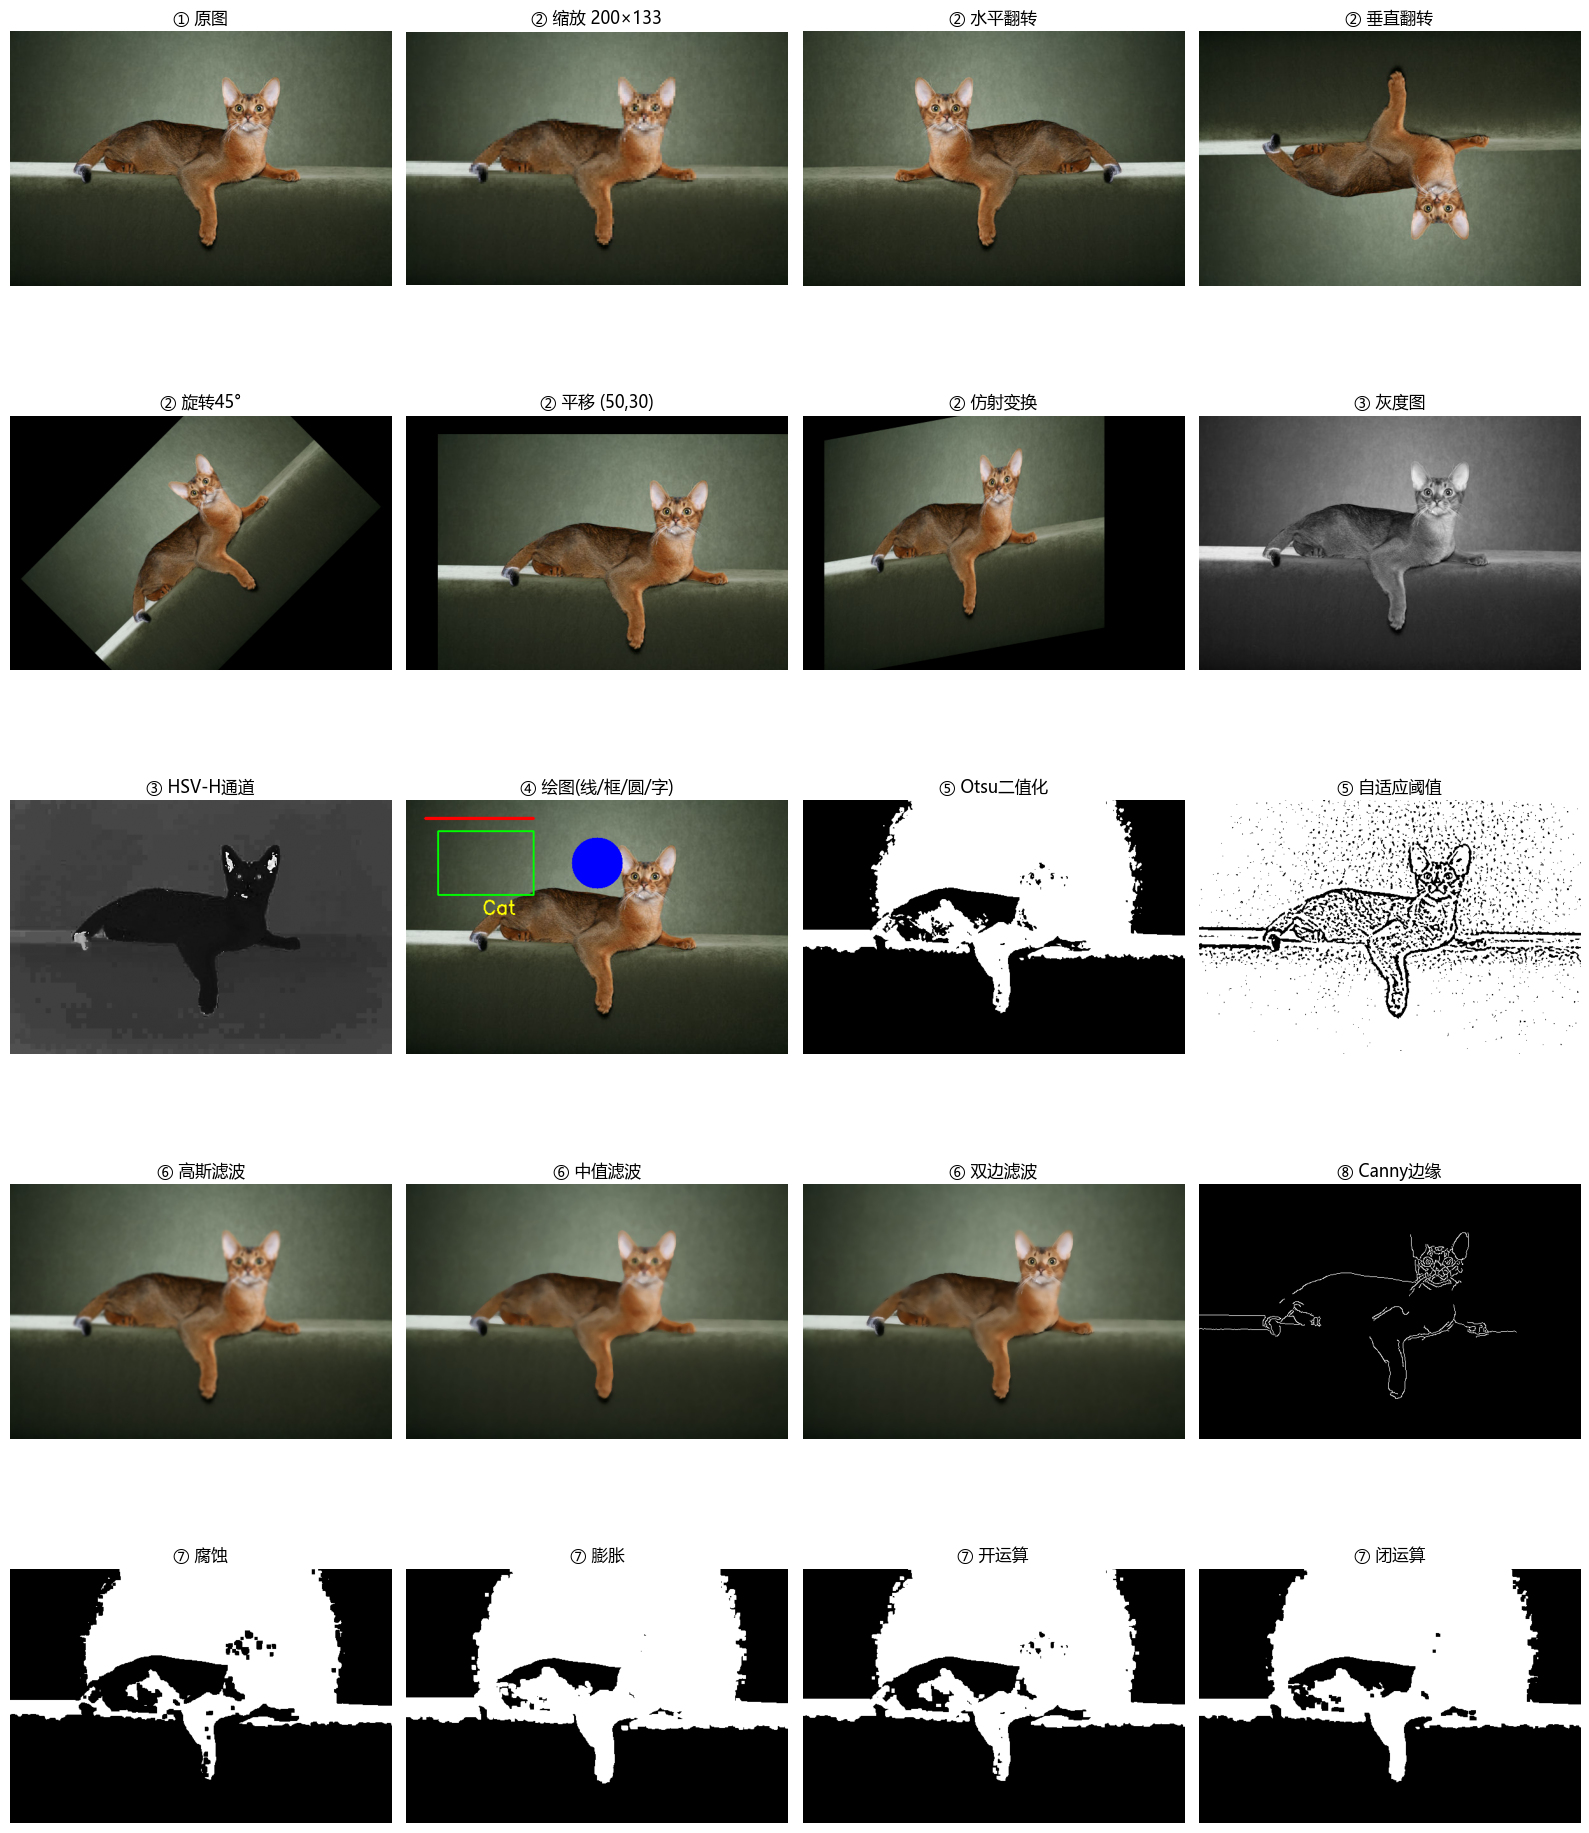


📝 OpenCV vs PIL 对照

功能          OpenCV                          PIL
─────        ──────                         ──────
读图          cv2.imread()                   Image.open()
读写颜色      BGR（注意！）                   RGB
几何变换      warpAffine / flip               transpose / rotate / resize
颜色空间      cvtColor(BGR2GRAY/HSV/LAB)     convert('L'/'HSV')
绘图          cv2.line / rectangle / circle  ImageDraw.line / text
滤波          cv2.GaussianBlur / medianBlur  ImageFilter.GaussianBlur
形态学        cv2.erode / dilate / ...       无（需用 NumPy 模拟）
边缘检测      cv2.Canny                       无
轮廓          cv2.findContours                 无



In [5]:
# ============================================================
# OpenCV 基本操作演示 —— 以猫咪图片为例
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- 设置中文 ----------
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# ---------- 1. 读写与显示 ----------
img = cv2.imread('images/Abyssinian_1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 转 RGB 供 matplotlib 显示
h, w = img.shape[:2]
print(f"① 读取: shape={img.shape}, dtype={img.dtype}")
print(f"   OpenCV 默认 BGR, 已转为 RGB")

# ---------- 2. 几何变换 ----------
# 缩放
resized = cv2.resize(img_rgb, (200, 133))

# 翻转
flip_h = cv2.flip(img_rgb, 1)    # 水平
flip_v = cv2.flip(img_rgb, 0)    # 垂直

# 旋转（绕中心 45°）
center = (w // 2, h // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 0.8)
rotated = cv2.warpAffine(img_rgb, M_rot, (w, h))

# 平移 (50, 30)
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(img_rgb, M_trans, (w, h))

# 仿射变换（三点映射）
src_pts = np.float32([[50,50], [200,50], [50,200]])
dst_pts = np.float32([[70,80], [180,60], [70,220]])
M_aff = cv2.getAffineTransform(src_pts, dst_pts)
affined = cv2.warpAffine(img_rgb, M_aff, (w, h))

print("② 几何变换完成: 缩放/翻转/旋转/平移/仿射")

# ---------- 3. 颜色空间 ----------
gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
hsv   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
print(f"③ 颜色转换: gray.shape={gray.shape}, HSV 范围 0~180,0~255,0~255")

# ---------- 4. 绘图 ----------
draw = img_rgb.copy()
cv2.line(draw, (30,30), (200,30), (255,0,0), 3)          # 蓝线
cv2.rectangle(draw, (50,50), (200,150), (0,255,0), 2)    # 绿框
cv2.circle(draw, (300,100), 40, (0,0,255), -1)           # 红实心圆
cv2.putText(draw, "Cat", (120,180), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)
print("④ 绘图完成: 线/矩形/圆/文字")

# ---------- 5. 阈值与二值化 ----------
# 先用高斯滤波去噪
blurred = cv2.GaussianBlur(gray, (5,5), 0)

# Otsu 自动阈值
_, binary_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 自适应阈值
binary_adapt = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
print("⑤ 二值化完成: Otsu + 自适应阈值")

# ---------- 6. 滤波与平滑 ----------
blur_mean  = cv2.blur(img_rgb, (7,7))                    # 均值
blur_gauss = cv2.GaussianBlur(img_rgb, (7,7), 0)         # 高斯
blur_median = cv2.medianBlur(img_rgb, 7)                 # 中值
blur_bilateral = cv2.bilateralFilter(img_rgb, 9, 75, 75) # 双边
print("⑥ 滤波完成: 均值/高斯/中值/双边")

# ---------- 7. 形态学操作 ----------
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
eroded  = cv2.erode(binary_otsu, kernel, iterations=1)
dilated = cv2.dilate(binary_otsu, kernel, iterations=1)
opening = cv2.morphologyEx(binary_otsu, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary_otsu, cv2.MORPH_CLOSE, kernel)
print("⑦ 形态学完成: 腐蚀/膨胀/开/闭")

# ---------- 8. 边缘检测 ----------
edges_canny = cv2.Canny(blurred, 50, 150)
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
print("⑧ 边缘检测完成: Canny + Sobel")

# ---------- 9. 轮廓检测 ----------
contours, _ = cv2.findContours(binary_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt_img = img_rgb.copy()
cv2.drawContours(cnt_img, contours, -1, (0,255,0), 2)
# 找出最大轮廓并画外接矩形
if contours:
    max_cnt = max(contours, key=cv2.contourArea)
    x, y, cw, ch = cv2.boundingRect(max_cnt)
    cv2.rectangle(cnt_img, (x, y), (x+cw, y+ch), (255,0,0), 2)
    cv2.putText(cnt_img, f"area={cv2.contourArea(max_cnt):.0f}", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
    print(f"⑨ 轮廓: 找到 {len(contours)} 个, 最大面积={cv2.contourArea(max_cnt):.0f}")
else:
    print("⑨ 轮廓: 未找到轮廓")

# ---------- 10. 图像运算 ----------
# 创建一张水印图做加法演示
watermark = np.zeros_like(img_rgb)
cv2.putText(watermark, "OPENCV", (100, 200), cv2.FONT_HERSHEY_DUPLEX, 2, (0,255,255), 3)
blended = cv2.addWeighted(img_rgb, 0.8, watermark, 0.2, 0)

# 位运算：提取猫的区域（用阈值做 mask）
_, mask = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
fg = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
bg = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_inv)
print("⑩ 图像运算完成: 加权融合 + 位运算 mask")

# ============================================================
# 绘制大图展示所有操作
# ============================================================
fig, axes = plt.subplots(5, 4, figsize=(16, 20))
axes = axes.flatten()

def show(ax, img_cv, title, cmap=None):
    """显示 OpenCV BGR 或灰度图"""
    if cmap:
        ax.imshow(img_cv, cmap=cmap)
    elif len(img_cv.shape) == 2:
        ax.imshow(img_cv, cmap='gray')
    else:
        ax.imshow(img_cv)
    ax.set_title(title)
    ax.axis('off')

show(axes[0], img_rgb, "① 原图")
show(axes[1], resized, "② 缩放 200×133")
show(axes[2], flip_h, "② 水平翻转")
show(axes[3], flip_v, "② 垂直翻转")
show(axes[4], rotated, "② 旋转45°")
show(axes[5], translated, "② 平移 (50,30)")
show(axes[6], affined, "② 仿射变换")
show(axes[7], gray, "③ 灰度图", cmap='gray')
show(axes[8], hsv[:,:,0], "③ HSV-H通道", cmap='gray')
show(axes[9], draw, "④ 绘图(线/框/圆/字)")
show(axes[10], binary_otsu, "⑤ Otsu二值化", cmap='gray')
show(axes[11], binary_adapt, "⑤ 自适应阈值", cmap='gray')
show(axes[12], blur_gauss, "⑥ 高斯滤波")
show(axes[13], blur_median, "⑥ 中值滤波")
show(axes[14], blur_bilateral, "⑥ 双边滤波")
show(axes[15], edges_canny, "⑧ Canny边缘", cmap='gray')
show(axes[16], eroded, "⑦ 腐蚀", cmap='gray')
show(axes[17], dilated, "⑦ 膨胀", cmap='gray')
show(axes[18], opening, "⑦ 开运算", cmap='gray')
show(axes[19], closing, "⑦ 闭运算", cmap='gray')
# 多余子图隐藏
for i in range(20, 20):
    axes[i].axis('off')

print("\n⑨ 轮廓图因空间限制已省略，结果见上方输出")

plt.tight_layout()
plt.show()

# ---------- 总结 ----------
print("\n" + "="*60)
print("📝 OpenCV vs PIL 对照")
print("="*60)
print("""
功能          OpenCV                          PIL
─────        ──────                         ──────
读图          cv2.imread()                   Image.open()
读写颜色      BGR（注意！）                   RGB
几何变换      warpAffine / flip               transpose / rotate / resize
颜色空间      cvtColor(BGR2GRAY/HSV/LAB)     convert('L'/'HSV')
绘图          cv2.line / rectangle / circle  ImageDraw.line / text
滤波          cv2.GaussianBlur / medianBlur  ImageFilter.GaussianBlur
形态学        cv2.erode / dilate / ...       无（需用 NumPy 模拟）
边缘检测      cv2.Canny                       无
轮廓          cv2.findContours                 无
""")


原图尺寸: 275x411
裁剪后尺寸: 274x410
网格尺寸: 137x205
  Patch 1: pos=(0,0) size=137x205
  Patch 2: pos=(137,0) size=137x205
  Patch 3: pos=(0,205) size=137x205
  Patch 4: pos=(137,205) size=137x205


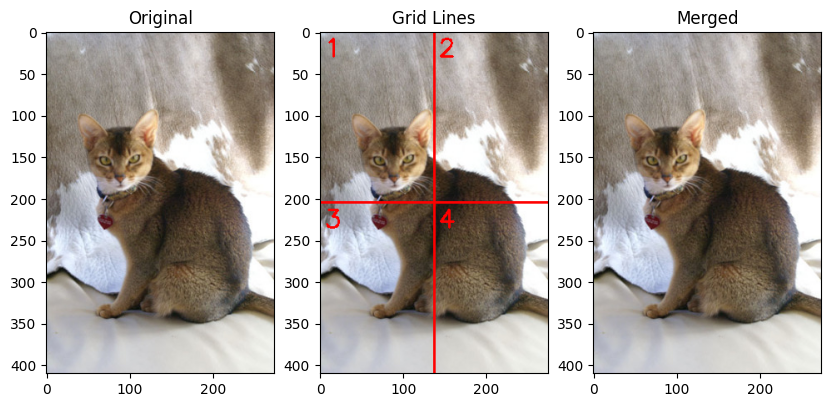

合并后的图与原图是否相同: True


In [ ]:
#作业1 将图像进行分割之后进行合并
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取图像
img = cv2.imread('images/Abyssinian_17.jpg')
h,w = img.shape[:2]
print(f"原图尺寸: {w}x{h}")

# 裁剪为偶数尺寸，避免整除丢失像素
img = img[:h//2*2, :w//2*2]
h,w = img.shape[:2]
print(f"裁剪后尺寸: {w}x{h}")

grid_h ,grid_w = h//2,w//2
print(f"网格尺寸: {grid_w}x{grid_h}")

# 1.5 画出分割线（在原图上画红色十字线）
img_grid = img.copy()
cv2.line(img_grid, (grid_w, 0), (grid_w, h), (0, 0, 255), 2)    # 竖线
cv2.line(img_grid, (0, grid_h), (w, grid_h), (0, 0, 255), 2)    # 横线
# 标上区块编号
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img_grid, "1", (5, 30), font, 1, (0, 0, 255), 2)
cv2.putText(img_grid, "2", (grid_w+5, 30), font, 1, (0, 0, 255), 2)
cv2.putText(img_grid, "3", (5, grid_h+30), font, 1, (0, 0, 255), 2)
cv2.putText(img_grid, "4", (grid_w+5, grid_h+30), font, 1, (0, 0, 255), 2)
#分割
patches = []
for i in range(2):
    for j in range(2):
        patch = img[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w]
        patches.append(patch)
        print(f"  Patch {i*2+j+1}: pos=({j*grid_w},{i*grid_h}) size={patch.shape[1]}x{patch.shape[0]}")

# 2. 按原顺序合并回完整图像
merged = np.zeros_like(img)
for i in range(2):
    for j in range(2):
        idx = i * 2 + j
        merged[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w] = patches[idx]

# 3. 显示对比
plt.figure(figsize=(10,5))
plt.subplot(131); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original')
plt.subplot(132); plt.imshow(cv2.cvtColor(img_grid, cv2.COLOR_BGR2RGB)); plt.title('Grid Lines')
plt.subplot(133); plt.imshow(cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)); plt.title('Merged')
plt.show()

# 4. 验证是否一致
print(f"合并后的图与原图是否相同: {np.allclose(img, merged)}")

共读取 4 条检测结果
  [0] conf=0.9157, bbox=(43.5,92.5,282.1,343.4), class=2
  [1] conf=0.6956, bbox=(207.9,75.1,372.5,334.2), class=1
  [2] conf=0.9157, bbox=(44.2,93.9,281.4,342.2), class=2
  [3] conf=0.6960, bbox=(207.1,74.0,373.1,335.1), class=1

最佳检测: conf=0.9157, bbox=(44,93,281,342), class=2
背景图尺寸: 1683x1051
角色图尺寸: 1354x1033


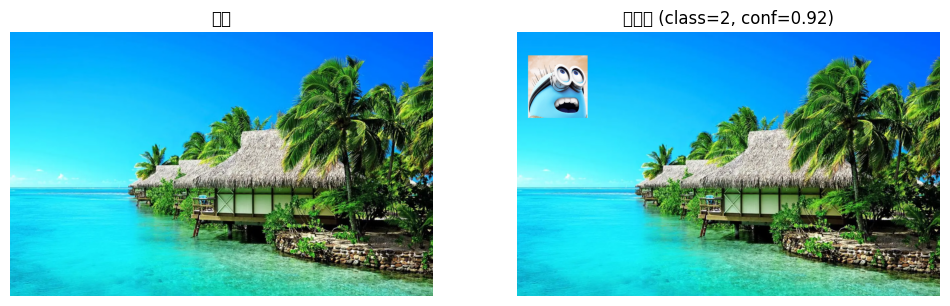

已保存: test7/result.png


In [ ]:
#作业2 读取检测结果，将置信度最高的目标粘贴到背景图上
# ============================================================
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取 JSON Lines 文件（每行是一个独立 JSON 数组）
json_path = "test7/data.json"
rows = []
with open(json_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

print(f"共读取 {len(rows)} 条检测结果")
for i, row in enumerate(rows):
    print(f"  [{i}] conf={row[0]:.4f}, bbox=({row[1]:.1f},{row[2]:.1f},{row[3]:.1f},{row[4]:.1f}), class={int(row[5])}")

# 2. 找出第一个元素（置信度）最大的行
best = max(rows, key=lambda r: r[0])
conf = best[0]
x1, y1, x2, y2 = map(int, best[1:5])   # 坐标取整
cls_id = int(best[5])
print(f"\n最佳检测: conf={conf:.4f}, bbox=({x1},{y1},{x2},{y2}), class={cls_id}")

# 3. 加载背景图（原图）
bg_path = "data/bg_imgs/01.png"
bg = cv2.imread(bg_path)
bg = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)
print(f"背景图尺寸: {bg.shape[1]}x{bg.shape[0]}")

# 4. 根据类别 ID 加载对应的小黄人图片
#    class=1 → 01.png, class=2 → 02.png（可根据实际调整）
char_path = f"test7/xhr_imgs/{cls_id:02d}.png"
char = cv2.imread(char_path, cv2.IMREAD_UNCHANGED)  # 保留 alpha 通道
if char is None:
    char = cv2.imread(char_path)
print(f"角色图尺寸: {char.shape[1]}x{char.shape[0]}")

# 5. 将角色缩放到 bbox 大小，然后粘贴到背景上
char_h = y2 - y1
char_w = x2 - x1
char_resized = cv2.resize(char, (char_w, char_h))

# 如果有 alpha 通道，做透明混合；否则直接覆盖
result = bg.copy()
if char_resized.shape[2] == 4:
    # 带透明通道：用 alpha 做加权融合
    alpha = char_resized[:, :, 3] / 255.0
    for c in range(3):
        result[y1:y2, x1:x2, c] = (1 - alpha) * result[y1:y2, x1:x2, c] + alpha * char_resized[:, :, c]
else:
    # 无透明通道：直接覆盖
    result[y1:y2, x1:x2] = char_resized

# 6. 显示结果
plt.figure(figsize=(12, 6))
plt.subplot(121); plt.imshow(bg); plt.title('原图'); plt.axis('off')
plt.subplot(122); plt.imshow(result); plt.title(f'粘贴后 (class={cls_id}, conf={conf:.2f})'); plt.axis('off')
plt.show()

# 7. 保存结果
cv2.imwrite('test7/result.png', cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
print("已保存: test7/result.png")